In [30]:
import sys
!{sys.executable} -m pip install vaderSentiment

In [31]:
import pandas as pd
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [32]:
data = pd.read_csv('116 - book-reviews-sample.csv')
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   index       100 non-null    int64 
 1   reviewText  100 non-null    object
 2   rating      100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [34]:
data['clean_reviewText'] = data['reviewText'].str.lower()
data.head()

,index,reviewText,rating,clean_reviewText
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin..."
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [35]:
data['clean_reviewText'] = data['clean_reviewText'].apply(lambda x: re.sub("[^\w\s]","",x))
data.head()

,index,reviewText,rating,clean_reviewText
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [36]:
SentimentIntensityAnalyzer = SentimentIntensityAnalyzer()

In [37]:
def sentiment_checker(sentence):
    print(sentence)
    print( SentimentIntensityAnalyzer.polarity_scores(sentence))

data['clean_reviewText'].apply(lambda x: sentiment_checker(x))

clean and funny a bit busy with all the different plots going on but overall a good read bye now
{'neg': 0.0, 'neu': 0.69, 'pos': 0.31, 'compound': 0.7684}
alex a sexy hot cop and the phd candidate what a match that makes for a great fun and exciting book
{'neg': 0.0, 'neu': 0.548, 'pos': 0.452, 'compound': 0.9325}
good thing that this is a free story i read it a few years ago and it is not worth the time
{'neg': 0.062, 'neu': 0.707, 'pos': 0.231, 'compound': 0.674}
action action action equipment keeps getting blown up but the heroes live on and on
{'neg': 0.0, 'neu': 0.759, 'pos': 0.241, 'compound': 0.6652}
this was hands down the worse book i have ever read and trst me that says alot
{'neg': 0.162, 'neu': 0.838, 'pos': 0.0, 'compound': -0.4767}
great book packed full with fast cars  crazy hot men and danger and oh yes great sex
{'neg': 0.202, 'neu': 0.418, 'pos': 0.38, 'compound': 0.7269}
i enjoyed the readers digest very much if i could figure out how to get it on my kinkle i would


0     None
1     None
2     None
3     None
4     None
      ... 
95    None
96    None
97    None
98    None
99    None
Name: clean_reviewText, Length: 100, dtype: object

In [38]:
data['vader-score'] = data['clean_reviewText'].apply(lambda x:  SentimentIntensityAnalyzer.polarity_scores(x)['compound'])
data.head()

,index,reviewText,rating,clean_reviewText,vader-score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [39]:
bin = [-1.0,-0.1,0.1,1.0]
emotions = ['negative','neutral','positive']

data['vader-label'] = pd.cut(data['vader-score'],bins= bin, labels= emotions)
data.head()

,index,reviewText,rating,clean_reviewText,vader-score,vader-label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative


<Axes: ylabel='vader-label'>

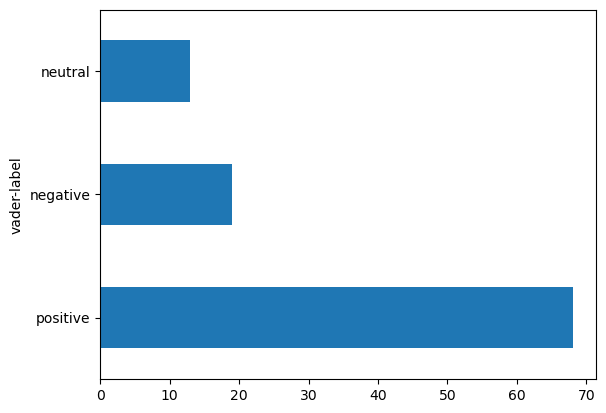

In [40]:
data['vader-label'].value_counts().plot.barh()

In [41]:
import transformers
from transformers import pipeline

In [42]:
sentiment_analysis = pipeline('sentiment-analysis')

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [44]:
transform_labels = []

for reviews in data['clean_reviewText'].values:
    sentiment_list = sentiment_analysis(reviews)
    transform_labels.append([sub['label'] for sub in sentiment_list])

data['transform-labels'] = transform_labels
data.head()
    

,index,reviewText,rating,clean_reviewText,vader-score,vader-label,transform-labels
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive,[POSITIVE]
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive,[POSITIVE]
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive,[NEGATIVE]
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive,[NEGATIVE]
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative,[NEGATIVE]


<Axes: xlabel='transform-labels'>

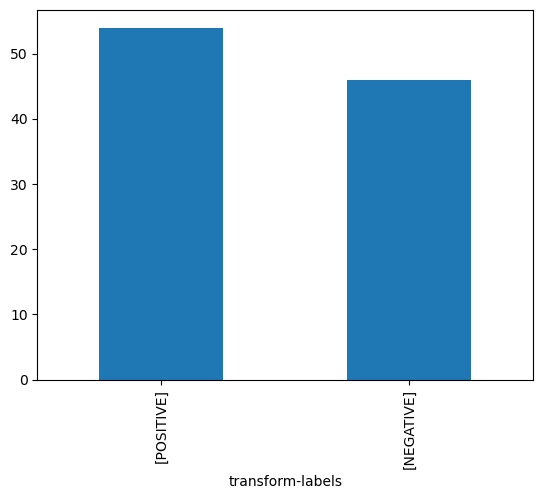

In [47]:
data['transform-labels'].value_counts().plot.bar()

In [48]:
specific_model = pipeline('sentiment-analysis', model= f"cardiffnlp/twitter-roberta-base-sentiment-latest")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
